## Cell 1 — Imports & Session Timer


In [1]:
import os, time, json, subprocess, shutil
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

SESSION_START     = time.time()
SESSION_LIMIT_HRS = 11.0

def hours_elapsed():
    return (time.time() - SESSION_START) / 3600

def session_ok(buffer_hrs=0.5):
    """Returns False when within buffer_hrs of the 11-hr Kaggle limit."""
    return hours_elapsed() < (SESSION_LIMIT_HRS - buffer_hrs)

print(f'Session limit: {SESSION_LIMIT_HRS} hrs')


Device: cuda
GPU : NVIDIA RTX PRO 6000 Blackwell Server Edition
VRAM: 102.0 GB
Session limit: 11.0 hrs


## Cell 2 — Streaming Multi-Part Extraction
No combined zip is ever written to disk.


In [2]:
import io, zipfile, shutil
from pathlib import Path

INPUT_BASE = Path('/kaggle/input')

parts = sorted(
    [
        f for f in INPUT_BASE.rglob('*')
        if f.is_file()
        and f.name.upper().startswith('MMRDR.ZIP.')
        and f.suffix.lstrip('.').isdigit()
    ],
    key=lambda p: int(p.suffix.lstrip('.'))
)

print(f'Found {len(parts)} zip parts:')
for p in parts:
    print(f'  {p}  ({p.stat().st_size / 1e6:.1f} MB)')

assert len(parts) == 9, (
    f'Expected 9 parts, found {len(parts)}. '
    'Attach the dataset containing MMRDR.zip.001 to MMRDR.zip.009 via Add Data.'
)

total_zip_gb = sum(p.stat().st_size for p in parts) / 1e9
free_gb = shutil.disk_usage('/kaggle/working').free / 1e9
print(f'Total compressed : {total_zip_gb:.2f} GB')
print(f'Free disk space  : {free_gb:.2f} GB')
print('Strategy         : streaming extraction (no combined zip on disk)')


class MultiPartReader(io.RawIOBase):
    def __init__(self, paths):
        self._paths   = list(paths)
        self._sizes   = [p.stat().st_size for p in self._paths]
        self._offsets = []
        off = 0
        for s in self._sizes:
            self._offsets.append(off)
            off += s
        self._total = off
        self._pos   = 0
        self._fh    = None
        self._cur   = -1

    def readable(self):  return True
    def seekable(self):  return True

    def readinto(self, b):
        if self._pos >= self._total:
            return 0
        n_want, n_read = len(b), 0
        while n_want > 0 and self._pos < self._total:
            idx      = self._part_for(self._pos)
            part_off = self._pos - self._offsets[idx]
            avail    = self._sizes[idx] - part_off
            to_read  = min(n_want, avail)
            self._open_part(idx)
            self._fh.seek(part_off)
            chunk  = self._fh.read(to_read)
            actual = len(chunk)
            if actual == 0:
                break
            b[n_read:n_read + actual] = chunk
            n_read    += actual
            n_want    -= actual
            self._pos += actual
        return n_read

    def seek(self, pos, whence=0):
        if   whence == 0: self._pos = pos
        elif whence == 1: self._pos = self._pos + pos
        elif whence == 2: self._pos = self._total + pos
        self._pos = max(0, min(self._pos, self._total))
        return self._pos

    def tell(self): return self._pos

    def _part_for(self, pos):
        lo, hi = 0, len(self._offsets) - 1
        while lo < hi:
            mid = (lo + hi + 1) // 2
            if self._offsets[mid] <= pos: lo = mid
            else:                         hi = mid - 1
        return lo

    def _open_part(self, idx):
        if self._cur != idx:
            if self._fh: self._fh.close()
            self._fh  = open(self._paths[idx], 'rb')
            self._cur = idx

    def close(self):
        if self._fh: self._fh.close()
        super().close()


EXTRACT_BASE = Path('/kaggle/working/mmrdr_extracted')
EXTRACT_BASE.mkdir(parents=True, exist_ok=True)
_READ_BUFFER = 4 << 20  # 4 MB


def _open_virtual_zip():
    raw = MultiPartReader(parts)
    buf = io.BufferedReader(raw, buffer_size=_READ_BUFFER)
    return zipfile.ZipFile(buf, 'r')


def _zip_prefix_for(modality_name):
    with _open_virtual_zip() as zf:
        members = zf.namelist()
    for prefix in [f'MMRDR/{modality_name}/', f'{modality_name}/']:
        if any(m.startswith(prefix) for m in members):
            return prefix
    top = sorted({m.split('/')[0] for m in members if m})
    raise FileNotFoundError(
        f'Cannot find {modality_name!r} in zip. Top-level folders: {top}'
    )


def extract_modality(modality_name, dest_dir=None):
    """Stream-extract one modality. The combined zip is NEVER written to disk."""
    dest_dir = Path(dest_dir or EXTRACT_BASE)
    dest_dir.mkdir(parents=True, exist_ok=True)
    prefix = _zip_prefix_for(modality_name)
    t0 = time.time()
    with _open_virtual_zip() as zf:
        members = [m for m in zf.namelist() if m.startswith(prefix)]
        n = len(members)
        print(f'  Extracting {n:,} entries for {modality_name}...')
        for i, member in enumerate(members, 1):
            zf.extract(member, dest_dir)
            if i % 500 == 0 or i == n:
                free = shutil.disk_usage('/kaggle/working').free / 1e9
                print(f'    {i:,}/{n:,} done  |  disk free: {free:.1f} GB', end='\r')
    print()
    modality_dir = dest_dir / prefix.rstrip('/')
    print(f'  Done in {time.time()-t0:.0f}s  ->  {modality_dir}')
    return modality_dir


# Scan zip contents without extracting
print('\nScanning zip contents...')
with _open_virtual_zip() as zf:
    all_members = zf.namelist()
top_folders = sorted({m.split('/')[0] for m in all_members if m})
print(f'  Total entries : {len(all_members):,}')
print(f'  Top-level folders : {top_folders}')
print('Ready.')


Found 9 zip parts:
  /kaggle/input/datasets/sanchitgarg999/mmrdr001/MMRDR.zip.001  (2097.2 MB)
  /kaggle/input/datasets/sanchitgarg999/mmrdr002/MMRDR.zip.002  (2097.2 MB)
  /kaggle/input/datasets/sanchitgarg999/mmrdr003/MMRDR.zip.003  (2097.2 MB)
  /kaggle/input/datasets/sanchitgarg999/mmrdr004/MMRDR.zip.004  (2097.2 MB)
  /kaggle/input/datasets/sanchitgarg999/mmrdr005/MMRDR.zip.005  (2097.2 MB)
  /kaggle/input/datasets/sanchitgarg999/mmrdr006/MMRDR.zip.006  (2097.2 MB)
  /kaggle/input/datasets/sanchitgarg999/mmrdr007/MMRDR.zip.007  (2097.2 MB)
  /kaggle/input/datasets/sanchitgarg999/mmrdr008/MMRDR.zip.008  (2097.2 MB)
  /kaggle/input/datasets/sanchitgarg999/mmrdr009/MMRDR.zip.009  (1833.1 MB)
Total compressed : 18.61 GB
Free disk space  : 20.94 GB
Strategy         : streaming extraction (no combined zip on disk)

Scanning zip contents...
  Total entries : 24,469
  Top-level folders : ['MMRDR-CFP', 'MMRDR-OCT', 'MMRDR-UWF']
Ready.


## Cell 3 — Configuration


In [3]:
OUTPUT_DIR = Path('/kaggle/working/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

CFG = {
    'img_size'    : 512,
    'batch_size'  : 16,
    'num_workers' : 4,
    'epochs'      : 30,
    'lr'          : 3e-4,
    'weight_decay': 1e-4,
    'patience'    : 6,
    'val_split'   : 0.125,  # 1/8 of train rows → ~7:1 train:val
}

print('Configuration:')
for k, v in CFG.items():
    print(f'  {k:<14} = {v}')
print(f'  OUTPUT_DIR     = {OUTPUT_DIR}')


Configuration:
  img_size       = 512
  batch_size     = 16
  num_workers    = 4
  epochs         = 30
  lr             = 0.0003
  weight_decay   = 0.0001
  patience       = 6
  val_split      = 0.125
  OUTPUT_DIR     = /kaggle/working/outputs


## Cell 4 — Data Transforms
### FIX 5: OCT-Specific Augmentation
ColorJitter excluded: OCT intensity encodes tissue reflectance. RandomVerticalFlip excluded: inverts inner/outer retina in B-scans.


In [4]:
# ── Standard transforms (for baseline ResNet-50 on OCT) ──────────────────────
# These match the transforms used in the Phase 2 UWF notebook for consistency.
train_transform = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── OCT-specific transforms (FIX 5) ──────────────────────────────────────────
#
# OCT images store grayscale information in RGB channels.
# ColorJitter is EXCLUDED because:
#   - brightness: corrupts tissue reflectance signal
#   - contrast:   destroys retinal layer boundary visibility
#   - saturation: creates false cross-channel differences in grayscale-as-RGB
# RandomVerticalFlip is EXCLUDED: flipping a B-scan inverts inner/outer retina
#   (anatomically invalid — NFL/GCL become RPE/Bruch's membrane)
# RandomHorizontalFlip is SAFE: OCT B-scans have left-right symmetry
# RandomRotation(10): simulates scanner tilt (conservative ±10°)
# RandomAffine(translate=(0.05, 0.05)): simulates foveal centring variation

oct_train_transform = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

oct_val_transform = transforms.Compose([
    transforms.Resize((CFG['img_size'], CFG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print('Standard transforms   : train_transform, val_test_transform')
print('OCT-specific transforms: oct_train_transform, oct_val_transform')
print('  (ColorJitter excluded | RandomVerticalFlip excluded)')


Standard transforms   : train_transform, val_test_transform
OCT-specific transforms: oct_train_transform, oct_val_transform
  (ColorJitter excluded | RandomVerticalFlip excluded)


## Cell 5 — Dataset Classes
### FIX 4: OCT uses MMRDRGradingDataset (2-tuple). MMRDRGradingDatasetGAT (3-tuple with lr) is NOT used for OCT.


In [5]:
# ── MMRDRGradingDataset: 2-tuple (image, label) ──────────────────────────────
# Used by: OCT baseline AND OCT GAT (FIX 4: no lr flag for OCT)

class MMRDRGradingDataset(Dataset):
    """Single-label grading dataset. Returns (image, label)."""

    def __init__(self, df, img_dir, transform=None):
        self.df        = df.reset_index(drop=True)
        self.img_dir   = Path(img_dir)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        img_val = str(row['image'])
        img_path = self.img_dir / img_val
        if not img_path.exists():
            img_path = self.img_dir / 'img' / Path(img_val).name
        if not img_path.exists():
            raise FileNotFoundError(f'Image not found: {img_val}')

        image = Image.open(img_path).convert('RGB')
        label = int(row['grade'])

        if self.transform:
            image = self.transform(image)
        return image, label


# ── OCT DataLoader factory (FIX 4: 2-tuple, OCT transforms) ──────────────────
def make_oct_loaders(train_df, val_df, test_df, img_dir):
    """DataLoaders for OCT — no lr flag, uses OCT-specific transforms."""
    tr = DataLoader(
        MMRDRGradingDataset(train_df, img_dir, oct_train_transform),
        batch_size=CFG['batch_size'], shuffle=True,
        num_workers=CFG['num_workers'], pin_memory=True)
    vl = DataLoader(
        MMRDRGradingDataset(val_df, img_dir, oct_val_transform),
        batch_size=CFG['batch_size'], shuffle=False,
        num_workers=CFG['num_workers'], pin_memory=True)
    ts = DataLoader(
        MMRDRGradingDataset(test_df, img_dir, oct_val_transform),
        batch_size=CFG['batch_size'], shuffle=False,
        num_workers=CFG['num_workers'], pin_memory=True)
    return tr, vl, ts


# ── Standard loader factory (for baseline) ───────────────────────────────────
def make_loaders(train_df, val_df, test_df, img_dir, task='dme'):
    """DataLoaders for baseline ResNet-50 — uses standard transforms."""
    tr = DataLoader(
        MMRDRGradingDataset(train_df, img_dir, train_transform),
        batch_size=CFG['batch_size'], shuffle=True,
        num_workers=CFG['num_workers'], pin_memory=True)
    vl = DataLoader(
        MMRDRGradingDataset(val_df, img_dir, val_test_transform),
        batch_size=CFG['batch_size'], shuffle=False,
        num_workers=CFG['num_workers'], pin_memory=True)
    ts = DataLoader(
        MMRDRGradingDataset(test_df, img_dir, val_test_transform),
        batch_size=CFG['batch_size'], shuffle=False,
        num_workers=CFG['num_workers'], pin_memory=True)
    return tr, vl, ts


print('MMRDRGradingDataset defined (2-tuple: image, label).')
print('make_oct_loaders: uses oct_train_transform / oct_val_transform.')
print('make_loaders    : uses standard transforms (for baseline).')


MMRDRGradingDataset defined (2-tuple: image, label).
make_oct_loaders: uses oct_train_transform / oct_val_transform.
make_loaders    : uses standard transforms (for baseline).


## Cell 6 — CSV Loader & Train/Val Split


In [6]:
def load_csv_splits(modality_dir, csv_filename):
    """
    Reads annotation CSV, splits train rows into train/val (7:1).
    Images prefixed 'tr' = training, 'ts' = testing.
    """
    df = pd.read_csv(Path(modality_dir) / csv_filename)
    basenames = df['image'].apply(lambda p: Path(str(p)).name)
    train_mask = basenames.str.startswith('tr')
    test_mask  = basenames.str.startswith('ts')

    if train_mask.sum() == 0 and test_mask.sum() == 0:
        print(f'  WARNING: no tr/ts prefix. Falling back to 80/20 split.')
        train_df, test_df = train_test_split(df, test_size=0.2, random_state=SEED)
    elif train_mask.sum() == 0:
        print('  WARNING: no training rows; using test set for all splits.')
        train_df = df[test_mask].copy()
        test_df  = df[test_mask].copy()
    else:
        train_df = df[train_mask].copy()
        test_df  = df[test_mask].copy()

    if len(train_df) == 0:
        raise RuntimeError(
            f'Training set is empty. CSV: {Path(modality_dir) / csv_filename}\n'
            f'First 5 image values: {df["image"].head().tolist()}'
        )

    strat = None
    if 'grade' in train_df.columns:
        min_class_count = train_df['grade'].value_counts().min()
        n_val = max(1, int(len(train_df) * CFG['val_split']))
        n_classes = train_df['grade'].nunique()
        if min_class_count >= 2 and n_val >= n_classes:
            strat = train_df['grade']
        else:
            print(f'  NOTE: skipping stratify (min_class={min_class_count}, n_val={n_val})')

    train_df, val_df = train_test_split(
        train_df, test_size=CFG['val_split'], random_state=SEED, stratify=strat
    )
    print(f'  Train: {len(train_df):,} | Val: {len(val_df):,} | Test: {len(test_df):,}')
    return train_df, val_df, test_df


print('CSV loader defined.')


CSV loader defined.


## Cell 7 — ResNet-50 Model (Offline Weights) & Loss Functions


In [7]:
_RESNET50_WEIGHTS = next(Path('/kaggle/input').rglob('resnet50*.pth'), None)
if _RESNET50_WEIGHTS is None:
    _RESNET50_WEIGHTS = next(Path('/kaggle/input').rglob('resnet50*.pt'), None)

assert _RESNET50_WEIGHTS is not None, (
    'ResNet-50 weights file not found under /kaggle/input. '
    'Add your resnet50 weights dataset via Add Data.'
)
print(f'ResNet-50 weights: {_RESNET50_WEIGHTS}')


def build_resnet50(num_classes):
    """Load offline ResNet-50 ImageNet weights, replace FC for num_classes."""
    model = models.resnet50(weights=None)
    state_dict = torch.load(_RESNET50_WEIGHTS, map_location=DEVICE, weights_only=True)
    model.load_state_dict(state_dict)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(DEVICE)


def get_loss(task='dme'):
    """Return appropriate loss function for the task."""
    if task == 'dme':
        # Weighted CE for OCT DME (3-class: No DME / Mild / Severe)
        # Weights will be overridden dynamically by compute_class_weights()
        return nn.CrossEntropyLoss()
    return nn.CrossEntropyLoss()


def compute_class_weights(train_df, n_classes=3, label_col='grade'):
    """
    Compute inverse-frequency class weights for weighted CrossEntropyLoss.
    Returns FloatTensor of shape (n_classes,) on DEVICE.
    """
    counts  = train_df[label_col].value_counts().to_dict()
    total   = len(train_df)
    weights = torch.zeros(n_classes, dtype=torch.float32)
    for cls in range(n_classes):
        cnt = counts.get(cls, 1)
        weights[cls] = total / (n_classes * max(cnt, 1))
    weights = weights / weights.mean()
    return weights.to(DEVICE)


print('Model builder defined.')


ResNet-50 weights: /kaggle/input/datasets/sanchitgarg999/resnet50-imagenet-weights/resnet50-11ad3fa6.pth
Model builder defined.


## Cell 7B — OCT Graph Attention Network (Phase 3)

Implements all 10 surgical fixes from the Phase 3 plan:
- FIX 1: OCT image-type diagnostic
- FIX 2: Conditional ROI coordinates (B-scan vs En-face)
- FIX 3: Complete topology with PerifovealRing↔EdemaCandidate edge
- FIX 7: Complete EdemaCandidate specification (stride-4, detach, clamp)
- FIX 8: AMP-fixed GATLayer (float32 attention matrix)
- FIX 9: GlobalContext fan-out reduced to CentralFovea + EdemaCandidate only
- FIX 10: Documented gradient flow


In [8]:
# Cell 7B — OCT Graph Attention Network (Phase 3)
#
# Architecture overview:
#   ResNet-50 backbone (B×2048×16×16 for 512px input / stride-32)
#       ↓  RoI average-pool per OCT anatomical region
#   10-node graph (image-type dependent: B-scan or En-face ROIs)
#       ↓  Linear projection  2048 → 256 per node
#   GATLayer 1  (4 heads × 64 dim = 256 out, residual, LayerNorm)
#   GATLayer 2  (4 heads × 64 dim = 256 out, residual, LayerNorm)
#       ↓  Global attention readout  → 256-dim graph embedding
#   Linear(256 → N_OCT_CLASSES)  → DME grade logits
#
# Auxiliary head:
#   GAP(feature map) → Dropout → Linear(2048 → N_OCT_CLASSES)
#   Weighted 0.3× in total loss for stable early backbone training.

import gc


# ═══════════════════════════════════════════════════════════════════════
# FIX 2 — ROI Coordinate Tables (B-scan vs En-face)
# ═══════════════════════════════════════════════════════════════════════
# Coordinate system: (row_start_frac, row_end_frac, col_start_frac, col_end_frac)
# Fractions of feature-map spatial dimensions (H=W=16 for 512px / stride-32).
# Node 6 (EdemaCandidate) is None — computed dynamically in OCTGraphBuilder.forward()

_BSCAN_ROI_COORDS = [
    # 0  CentralFovea     — centre of B-scan depth/horizontal slice
    (0.20, 0.80, 0.35, 0.65),
    # 1  ParafovealSup    — upper-centre (inner retinal layers, superior)
    (0.05, 0.40, 0.25, 0.55),
    # 2  ParafovealInf    — lower-centre (inner retinal layers, inferior)
    (0.60, 0.95, 0.25, 0.55),
    # 3  ParafovealNasal  — nasal side
    (0.20, 0.80, 0.05, 0.30),
    # 4  ParafovealTemp   — temporal side
    (0.20, 0.80, 0.70, 0.95),
    # 5  PerifovealRing   — wide peripheral context
    (0.05, 0.95, 0.05, 0.95),
    # 6  EdemaCandidate   — DYNAMIC: computed at runtime from saliency argmax
    None,
    # 7  InnerRetina      — upper half (NFL → INL layers)
    (0.05, 0.45, 0.05, 0.95),
    # 8  OuterRetina      — lower half (OPL → RPE layers)
    (0.45, 0.95, 0.05, 0.95),
    # 9  GlobalContext    — full image
    (0.00, 1.00, 0.00, 1.00),
]

_BSCAN_NODE_NAMES = [
    'CentralFovea', 'ParafovealSup', 'ParafovealInf',
    'ParafovealNasal', 'ParafovealTemp', 'PerifovealRing',
    'EdemaCandidate', 'InnerRetina', 'OuterRetina', 'GlobalContext',
]

_ENFACE_ROI_COORDS = [
    # 0  CentralFovea     — central macular area
    (0.30, 0.70, 0.30, 0.70),
    # 1  SuperiorRegion   — spatial superior
    (0.00, 0.40, 0.20, 0.80),
    # 2  InferiorRegion   — spatial inferior
    (0.60, 1.00, 0.20, 0.80),
    # 3  NasalRegion      — nasal side
    (0.20, 0.80, 0.00, 0.35),
    # 4  TemporalRegion   — temporal side
    (0.20, 0.80, 0.65, 1.00),
    # 5  PerifovealRing   — peripheral context ring
    (0.05, 0.95, 0.05, 0.95),
    # 6  EdemaCandidate   — DYNAMIC
    None,
    # 7  SuperiorHemi     — upper spatial half
    (0.05, 0.45, 0.05, 0.95),
    # 8  InferiorHemi     — lower spatial half
    (0.45, 0.95, 0.05, 0.95),
    # 9  GlobalContext    — full image
    (0.00, 1.00, 0.00, 1.00),
]

_ENFACE_NODE_NAMES = [
    'CentralFovea', 'SuperiorRegion', 'InferiorRegion',
    'NasalRegion', 'TemporalRegion', 'PerifovealRing',
    'EdemaCandidate', 'SuperiorHemi', 'InferiorHemi', 'GlobalContext',
]

OCT_N_NODES = 10


# ═══════════════════════════════════════════════════════════════════════
# FIX 3 — Adjacency Builder (57 directed edges, PerifovealRing↔EdemaCandidate added)
# ═══════════════════════════════════════════════════════════════════════
def _build_oct_adjacency():
    """
    Build edge-index tensor (2, E) for the 10-node OCT anatomical graph.

    Edge summary (57 directed edges):
      CentralFovea(0)  ↔ Parafoveal(1-4)        8 edges
      Parafoveal ring  (1↔3, 3↔2, 2↔4, 4↔1)    8 edges
      Parafoveal(1-4)  ↔ PerifovealRing(5)      8 edges
      Layer/Hemi nodes (7↔8, 7↔0, 8↔0)         6 edges
      EdemaCandidate(6)↔ CentralFovea(0)        2 edges
      EdemaCandidate(6)↔ Node7                  2 edges
      EdemaCandidate(6)↔ PerifovealRing(5)      2 edges  ← FIX 3
      EdemaCandidate(6)↔ GlobalContext(9)       2 edges
      GlobalContext(9) ← nodes 0-5, 7-8         8 fan-in edges
        (node 6 → GlobalContext already counted above)
      GlobalContext(9) → CentralFovea(0)        1 fan-out edge  ← FIX 9 reduced
        (GlobalContext → EdemaCandidate already counted above)
      Self-loops (all 10 nodes)                10 edges
      ──────────────────────────────────────────────────
      Total (after set deduplication)          57 directed edges

    NOTE on deduplication: edges are stored in a set(), so duplicates from
    overlapping construction blocks are automatically collapsed.
      (6,9) and (9,6) added in EdemaCandidate block → fan-in loop's (6,9)
      and fan-out's (9,6) are no-ops, yielding 57 not 59.
    """
    edges = set()

    # CentralFovea ↔ Parafoveal (nodes 1-4)
    for p in [1, 2, 3, 4]:
        edges.add((0, p)); edges.add((p, 0))

    # Adjacent parafoveal ring: Sup↔Nasal, Nasal↔Inf, Inf↔Temp, Temp↔Sup
    for a, b in [(1, 3), (3, 2), (2, 4), (4, 1)]:
        edges.add((a, b)); edges.add((b, a))

    # Parafoveal ↔ PerifovealRing
    for p in [1, 2, 3, 4]:
        edges.add((p, 5)); edges.add((5, p))

    # Layer/Hemi nodes: 7↔8, 7↔CentralFovea, 8↔CentralFovea
    edges.add((7, 8)); edges.add((8, 7))
    edges.add((7, 0)); edges.add((0, 7))
    edges.add((8, 0)); edges.add((0, 8))

    # EdemaCandidate connections
    edges.add((6, 0)); edges.add((0, 6))   # ↔ CentralFovea
    edges.add((6, 7)); edges.add((7, 6))   # ↔ InnerRetina / SuperiorHemi
    edges.add((6, 5)); edges.add((5, 6))   # ↔ PerifovealRing  ← FIX 3
    edges.add((6, 9)); edges.add((9, 6))   # ↔ GlobalContext

    # GlobalContext: full fan-in from all 9 non-global nodes
    # (6,9) already added above — set deduplication handles overlap
    for n in range(9):
        edges.add((n, 9))           # fan-in: every node → GlobalContext
    edges.add((9, 0))               # fan-out → CentralFovea only        ← FIX 9
    # (9,6) already added in EdemaCandidate block — no-op here            ← FIX 9

    # Self-loops (CRITICAL: prevents all-(-inf) softmax rows in GATLayer)
    for i in range(OCT_N_NODES):
        edges.add((i, i))

    src, dst = zip(*sorted(edges))
    return torch.tensor([list(src), list(dst)], dtype=torch.long)


_OCT_EDGE_INDEX_CPU = _build_oct_adjacency()
print(f'OCT adjacency: {OCT_N_NODES} nodes, {_OCT_EDGE_INDEX_CPU.shape[1]} directed edges')
assert _OCT_EDGE_INDEX_CPU.shape[1] == 57, (
    f'Expected 57 edges, got {_OCT_EDGE_INDEX_CPU.shape[1]}'
)


# ═══════════════════════════════════════════════════════════════════════
# FIX 7 — Edema Candidate ROI (stride-4, non-overlapping, detached saliency)
# ═══════════════════════════════════════════════════════════════════════
def _find_edema_candidate_roi(feat_map, patch_size=4):
    """
    Find the highest-activation non-overlapping patch in the feature map.

    GRADIENT FLOW (FIX 10):
      feat_map ──────────────────────────────► _roi_pool() ──► node_feats[b,6,:]
           │                                      ↑
           │                                      │ coordinates (no gradient)
           └──► .mean(dim=1) ──► .detach() ──► argmax ──► (r0,r1,c0,c1)
                                   ↑
                              STOP GRADIENT

      ✓ Gradients flow: feat_map → _roi_pool → node_feats → GATLayer → loss
      ✗ Gradients do NOT flow: through coordinate selection (argmax of detached)
      ✓ Effect: backbone learns what to extract, not where to look (stable training)

    Args:
        feat_map  : (B, C, H, W) — from ResNet50Backbone, typically (B, 2048, 16, 16)
        patch_size: int — side length of candidate patches (default 4)
                    With H=W=16: 16//4 = 4 patches per axis → 16 candidates total

    Returns:
        r0, r1, c0, c1 : each (B,) float tensors — fractional coordinates in [0,1]
    """
    # 1. Saliency map — DETACHED (stop-gradient for coordinate selection)
    saliency = feat_map.mean(dim=1).detach()  # (B, H, W)
    B, H, W  = saliency.shape
    ph, pw   = patch_size, patch_size
    nH, nW   = H // ph, W // pw              # 16//4 = 4 → 4×4 = 16 candidates

    assert H >= ph and W >= pw, (
        f'Feature map {H}×{W} too small for patch {ph}×{pw}'
    )

    # 2. Reshape into non-overlapping patches, mean-pool each patch
    patches      = saliency[:, :nH*ph, :nW*pw]           # crop to exact multiple
    patches      = patches.reshape(B, nH, ph, nW, pw)    # (B, nH, ph, nW, pw)
    patches      = patches.permute(0, 1, 3, 2, 4)        # (B, nH, nW, ph, pw)
    patch_scores = patches.mean(dim=(-1, -2))             # (B, nH, nW)

    # 3. Argmax — one patch per image (non-differentiable, safe on detached saliency)
    flat_idx = patch_scores.reshape(B, -1).argmax(dim=1)  # (B,)
    row_idx  = flat_idx // nW
    col_idx  = flat_idx % nW

    # 4. Convert patch indices to fractional coordinates, clamp to [0,1]
    r0 = (row_idx.float() * ph / H).clamp(0.0, 1.0)
    r1 = ((row_idx.float() + 1) * ph / H).clamp(0.0, 1.0)
    c0 = (col_idx.float() * pw / W).clamp(0.0, 1.0)
    c1 = ((col_idx.float() + 1) * pw / W).clamp(0.0, 1.0)

    # 5. Guarantee non-degenerate ROI (min 1 pixel on feature map)
    r1 = torch.max(r1, r0 + 1.0 / H)
    c1 = torch.max(c1, c0 + 1.0 / W)

    return r0, r1, c0, c1


# ═══════════════════════════════════════════════════════════════════════
# RoI pooling helper (shared with Phase 1/2)
# ═══════════════════════════════════════════════════════════════════════
def _roi_pool(feat_map, r0f, r1f, c0f, c1f):
    """Average-pool a rectangular region of a spatial feature map."""
    _, _, H, W = feat_map.shape
    r0 = max(0, int(round(r0f * H)))
    r1 = min(H, max(r0 + 1, int(round(r1f * H))))
    c0 = max(0, int(round(c0f * W)))
    c1 = min(W, max(c0 + 1, int(round(c1f * W))))
    assert r1 > r0 and c1 > c0, (
        f'Degenerate ROI: rows [{r0},{r1}), cols [{c0},{c1}) '
        f'for H={H}, W={W}, fracs=({r0f:.3f},{r1f:.3f},{c0f:.3f},{c1f:.3f})'
    )
    region = feat_map[:, :, r0:r1, c0:c1]
    return region.mean(dim=(2, 3))


# ═══════════════════════════════════════════════════════════════════════
# FIX 1+2 — OCTGraphBuilder (image_type-aware, no lr_flags)
# ═══════════════════════════════════════════════════════════════════════
class OCTGraphBuilder(nn.Module):
    """
    Constructs a batch of 10-node OCT anatomical graphs from a spatial feature map.

    FIX 1: image_type parameter selects correct ROI coordinate table.
    FIX 2: B-scan uses depth-axis coordinates; En-face uses spatial coordinates.
    FIX 4: NO lr_flags argument — OCT images don't have optic disc laterality.

    For each image in the batch:
      - Extracts 9 static RoI-pooled feature vectors (nodes 0-5, 7-9)
      - Computes node 6 (EdemaCandidate) dynamically via saliency argmax
      - Saliency is DETACHED — coordinate selection has no gradient path
      - Actual EdemaCandidate pooling IS differentiable (from live feat_map)

    Contains NO learnable parameters — pure feature extractor.
    """

    def __init__(self, image_type='bscan'):
        super().__init__()
        if image_type == 'bscan':
            self.roi_coords = _BSCAN_ROI_COORDS
            self.node_names = _BSCAN_NODE_NAMES
        else:
            # 'enface' or 'unknown' — use spatial coordinates as safe fallback
            self.roi_coords = _ENFACE_ROI_COORDS
            self.node_names = _ENFACE_NODE_NAMES
        self.image_type = image_type

    def forward(self, feat_map):
        """
        Args:
            feat_map : (B, C, H, W) — ResNet-50 spatial feature map

        Returns:
            node_feats : (B, OCT_N_NODES, C)

        GRADIENT FLOW NOTE (FIX 10):
          - Static nodes (0-5, 7-9): _roi_pool is differentiable → gradients flow
          - EdemaCandidate (6): coordinates from DETACHED saliency, pooling is live
          - Therefore: feat_map receives gradients from all 10 nodes
        """
        B, C, H, W = feat_map.shape
        node_feats  = torch.zeros(B, OCT_N_NODES, C,
                                  device=feat_map.device, dtype=feat_map.dtype)

        # ── 1. Static nodes (all except node 6) ───────────────────────
        for node_idx, coords in enumerate(self.roi_coords):
            if node_idx == 6:
                continue  # EdemaCandidate handled below
            node_feats[:, node_idx, :] = _roi_pool(feat_map, *coords)

        # ── 2. EdemaCandidate (node 6) — dynamic saliency-based ROI ───
        # r0,r1,c0,c1 are (B,) tensors of fractional coords from DETACHED saliency
        r0, r1, c0, c1 = _find_edema_candidate_roi(feat_map)  # detach inside
        for b in range(B):
            # Pool from feat_map (NOT detached) — gradients flow through here
            node_feats[b, 6, :] = _roi_pool(
                feat_map[b:b+1],
                r0[b].item(), r1[b].item(),
                c0[b].item(), c1[b].item(),
            )[0]

        return node_feats   # (B, OCT_N_NODES, C)


# ═══════════════════════════════════════════════════════════════════════
# FIX 8 — GATLayer (AMP-fixed: float32 attention matrix)
# ═══════════════════════════════════════════════════════════════════════
class GATLayer(nn.Module):
    """
    Single multi-head Graph Attention layer — pure PyTorch, no external graph lib.

    Implements Veličković et al. (2018):
        e_ij  = LeakyReLU( a_k^T [ W_k h_i || W_k h_j ] )  per head k
        α_ij  = softmax_{j ∈ N(i) ∪ {i}}  e_ij             masked softmax
        h_i'  = concat_k  Σ_j α_ij^k  W_k h_j              multi-head agg
        h_i'' = LayerNorm( ELU( h_i' + W_res h_i ) )        residual + norm

    AMP FIX (FIX 8):
        attn_mat is created in float32 regardless of input dtype.
        .e is cast to float32 before filling attn_mat.
        This prevents float16 softmax instability under torch.amp.autocast.
        nan_to_num kept as second safety net; self-loops prevent degenerate rows.
    """

    def __init__(self, in_features, out_per_head, n_heads=4,
                 dropout=0.1, residual=True):
        super().__init__()
        self.n_heads      = n_heads
        self.out_per_head = out_per_head
        self.out_total    = out_per_head * n_heads
        self.residual     = residual

        self.W_heads    = nn.ModuleList([
            nn.Linear(in_features, out_per_head, bias=False) for _ in range(n_heads)
        ])
        self.attn_heads = nn.ModuleList([
            nn.Linear(2 * out_per_head, 1, bias=False) for _ in range(n_heads)
        ])

        self.leaky   = nn.LeakyReLU(negative_slope=0.2)
        self.dropout = nn.Dropout(dropout)
        self.norm    = nn.LayerNorm(self.out_total)

        if residual:
            self.res_proj = (
                nn.Linear(in_features, self.out_total, bias=False)
                if in_features != self.out_total else nn.Identity()
            )

        for attn in self.attn_heads:
            nn.init.normal_(attn.weight, std=0.01)

    def forward(self, x, edge_index):
        """
        Args:
            x          : (B, N, in_features)
            edge_index : (2, E)

        Returns:
            out : (B, N, out_total)
        """
        B, N, _ = x.shape
        src, dst = edge_index[0], edge_index[1]

        head_outputs = []
        for k in range(self.n_heads):
            h     = self.W_heads[k](x)                        # (B, N, out_per_head)
            h_src = h[:, src, :]                              # (B, E, out_per_head)
            h_dst = h[:, dst, :]                              # (B, E, out_per_head)
            edge_feat = torch.cat([h_src, h_dst], dim=-1)    # (B, E, 2*out_per_head)

            # AMP FIX: cast scores to float32 before filling attention matrix
            e = self.leaky(self.attn_heads[k](edge_feat)).squeeze(-1).float()  # (B,E) float32

            # Attention matrix in float32 (FIX 8 — prevents float16 softmax instability)
            attn_mat = torch.full((B, N, N), float('-inf'),
                                  device=x.device, dtype=torch.float32)
            attn_mat[:, dst, src] = e
            attn_mat = torch.softmax(attn_mat, dim=-1)
            attn_mat = torch.nan_to_num(attn_mat, nan=0.0, posinf=0.0, neginf=0.0)
            attn_mat = self.dropout(attn_mat)

            # Aggregate (cast h back to float32 if needed for bmm)
            agg = torch.bmm(attn_mat, h.float())              # (B, N, out_per_head)
            head_outputs.append(agg)

        out = torch.cat(head_outputs, dim=-1)                  # (B, N, out_total)

        if self.residual:
            out = out + self.res_proj(x).float()
        out = self.norm(out)
        out = F.elu(out)

        if out.isnan().any():
            out = torch.nan_to_num(out, nan=0.0)

        return out


# ═══════════════════════════════════════════════════════════════════════
# GraphReadout (REUSED from Phase 1/2)
# ═══════════════════════════════════════════════════════════════════════
class GraphReadout(nn.Module):
    """
    Global attention pooling: (B, N, D) → (B, D).
    Learns a trainable query vector. Returns attention weights for visualisation.
    """

    def __init__(self, embed_dim):
        super().__init__()
        self.query = nn.Parameter(torch.empty(embed_dim))
        nn.init.kaiming_uniform_(self.query.unsqueeze(0), a=0.2)

    def forward(self, x):
        scores = torch.matmul(x, self.query)           # (B, N)
        attn   = torch.softmax(scores, dim=-1)          # (B, N)
        graph_embed = (x * attn.unsqueeze(-1)).sum(1)   # (B, D)
        return graph_embed, attn


# ═══════════════════════════════════════════════════════════════════════
# ResNet50Backbone (REUSED from Phase 1/2)
# ═══════════════════════════════════════════════════════════════════════
class ResNet50Backbone(nn.Module):
    """ResNet-50 with avgpool and fc removed. Returns (feat_map, gap_feat)."""

    def __init__(self, pretrained_weights_path):
        super().__init__()
        base  = models.resnet50(weights=None)
        state = torch.load(pretrained_weights_path, map_location='cpu', weights_only=True)
        missing, unexpected = base.load_state_dict(state, strict=True)
        assert not missing and not unexpected, (
            f'ResNet-50 weight mismatch — missing: {missing}, unexpected: {unexpected}'
        )
        self.features = nn.Sequential(
            base.conv1, base.bn1, base.relu, base.maxpool,
            base.layer1, base.layer2, base.layer3, base.layer4,
        )
        self.gap = nn.AdaptiveAvgPool2d(1)

    def forward(self, x):
        feat_map = self.features(x)
        gap_feat = self.gap(feat_map).flatten(1)
        return feat_map, gap_feat


# ═══════════════════════════════════════════════════════════════════════
# OCTGATClassifier — full model (FIX 4: no lr_flags in forward)
# ═══════════════════════════════════════════════════════════════════════
class OCTGATClassifier(nn.Module):
    """
    Phase-3 full model: ResNet-50 backbone + OCT Anatomical GAT.

    Call signature (FIX 4 — no lr_flags):
        logits, aux_logits, attn_weights = model(images)

    Args:
        pretrained_weights_path : path to resnet50 .pth ImageNet weights
        n_classes    : DME grading classes (from CSV inspection — FIX 6)
        image_type   : 'bscan' | 'enface' | 'unknown'  (from diagnose_oct_images — FIX 1)
        proj_dim     : node embedding dimension after projection (default 256)
        n_heads      : GAT attention heads (default 4); proj_dim % n_heads == 0
        n_gat_layers : number of stacked GATLayers (default 2)
        dropout      : attention dropout (default 0.1)
        aux_weight   : loss weight for GAP auxiliary head (0 = disabled)
    """

    def __init__(self, pretrained_weights_path, n_classes=3,
                 image_type='bscan', proj_dim=256, n_heads=4,
                 n_gat_layers=2, dropout=0.1, aux_weight=0.3):
        super().__init__()
        assert proj_dim % n_heads == 0, (
            f'proj_dim ({proj_dim}) must be divisible by n_heads ({n_heads})'
        )
        backbone_dim   = 2048
        out_per_head   = proj_dim // n_heads
        self.aux_weight = aux_weight

        self.arch_cfg = dict(
            n_classes=n_classes, proj_dim=proj_dim, n_heads=n_heads,
            n_gat_layers=n_gat_layers, dropout=dropout, aux_weight=aux_weight,
            image_type=image_type,
        )

        # ── Backbone ──────────────────────────────────────────────────
        self.backbone = ResNet50Backbone(pretrained_weights_path)

        # ── OCT graph builder (FIX 1+2: image_type aware, no lr_flags) ──
        self.graph_builder = OCTGraphBuilder(image_type=image_type)

        # ── Node projection: 2048 → proj_dim ─────────────────────────
        self.node_proj = nn.Sequential(
            nn.Linear(backbone_dim, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.ReLU(inplace=True),
        )

        # ── Stacked GAT layers (FIX 8: AMP-fixed GATLayer) ──────────
        gat_layers = []
        for _ in range(n_gat_layers):
            gat_layers.append(
                GATLayer(proj_dim, out_per_head, n_heads, dropout, residual=True)
            )
        self.gat_layers = nn.ModuleList(gat_layers)

        # ── Graph readout ─────────────────────────────────────────────
        self.readout = GraphReadout(proj_dim)

        # ── DME grading head ──────────────────────────────────────────
        self.grading_head = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(proj_dim, n_classes),
        )

        # ── Auxiliary GAP head ────────────────────────────────────────
        if aux_weight > 0:
            self.aux_head = nn.Sequential(
                nn.Dropout(0.2),
                nn.Linear(backbone_dim, n_classes),
            )
        else:
            self.aux_head = None

        # Register edge index — moves with .to(device) automatically
        self.register_buffer('edge_index', _OCT_EDGE_INDEX_CPU.clone())

    def forward(self, images):
        """
        Args:
            images : (B, 3, H, W)  — normalised image batch

        Returns:
            logits       : (B, n_classes)
            aux_logits   : (B, n_classes) or None
            attn_weights : (B, OCT_N_NODES)  readout attention per node
        """
        # 1. Backbone → spatial feature map + GAP features
        feat_map, gap_feat = self.backbone(images)   # (B,2048,H',W'), (B,2048)

        # 2. Build OCT graph node features (FIX 4: no lr_flags)
        node_feats = self.graph_builder(feat_map)    # (B, OCT_N_NODES, 2048)

        # 3. Project to graph embedding dimension
        node_feats = self.node_proj(node_feats)       # (B, OCT_N_NODES, proj_dim)

        # 4. Pre-GAT NaN guard (defensive, rare under AMP)
        if node_feats.isnan().any():
            node_feats = torch.nan_to_num(node_feats, nan=0.0)

        # 5. Stacked GAT layers
        h = node_feats
        for layer in self.gat_layers:
            h = layer(h, self.edge_index)

        # 6. Graph readout → single graph embedding
        graph_embed, attn_weights = self.readout(h)  # (B,proj_dim), (B,OCT_N_NODES)

        # 7. Heads
        logits     = self.grading_head(graph_embed)
        aux_logits = self.aux_head(gap_feat) if self.aux_head is not None else None

        return logits, aux_logits, attn_weights


# ═══════════════════════════════════════════════════════════════════════
# Convenience constructors & checkpoint utilities
# ═══════════════════════════════════════════════════════════════════════
def build_oct_gat_model(n_classes=3, image_type='bscan', proj_dim=256,
                        n_heads=4, n_gat_layers=2, dropout=0.1, aux_weight=0.3):
    """
    Convenience constructor for OCTGATClassifier.
    n_classes and image_type must be determined BEFORE calling this (FIX 6).
    Uses the global _RESNET50_WEIGHTS path.
    """
    model = OCTGATClassifier(
        pretrained_weights_path=_RESNET50_WEIGHTS,
        n_classes=n_classes, image_type=image_type,
        proj_dim=proj_dim, n_heads=n_heads,
        n_gat_layers=n_gat_layers, dropout=dropout, aux_weight=aux_weight,
    )
    return model.to(DEVICE)


def save_oct_checkpoint(model, path, epoch=None, val_acc=None, val_f1=None):
    """Save OCTGATClassifier checkpoint with architecture metadata."""
    payload = {
        'state_dict' : model.state_dict(),
        'arch_cfg'   : model.arch_cfg,
        'epoch'      : epoch,
        'val_acc'    : val_acc,
        'val_f1'     : val_f1,
    }
    torch.save(payload, path)


def load_oct_checkpoint(model, path):
    """
    Load checkpoint saved by save_oct_checkpoint.
    Validates arch_cfg compatibility before loading weights.
    """
    ckpt    = torch.load(path, map_location=DEVICE, weights_only=False)
    stored  = ckpt.get('arch_cfg', {})
    current = model.arch_cfg
    for key in current:
        if key in stored:
            assert stored[key] == current[key], (
                f"Checkpoint arch mismatch for '{key}': "
                f"stored={stored[key]}, model={current[key]}"
            )
    model.load_state_dict(ckpt['state_dict'])
    meta = {k: ckpt.get(k) for k in ('epoch', 'val_acc', 'val_f1')}
    print(f"  Loaded checkpoint: epoch={meta['epoch']}, "
          f"val_acc={meta['val_acc']}, val_f1={meta['val_f1']}")
    return meta


# ── Sanity checks ──────────────────────────────────────────────────────────
print('OCT GAT components defined:')
print(f'  OCT_N_NODES   = {OCT_N_NODES}')
print(f'  Total edges   = {_OCT_EDGE_INDEX_CPU.shape[1]} directed edges (incl. self-loops)')
print(f'  B-scan nodes  : {_BSCAN_NODE_NAMES}')
print(f'  En-face nodes : {_ENFACE_NODE_NAMES}')
n_self   = (_OCT_EDGE_INDEX_CPU[0] == _OCT_EDGE_INDEX_CPU[1]).sum().item()
n_cross  = _OCT_EDGE_INDEX_CPU.shape[1] - n_self
print(f'  Cross-node: {n_cross} | Self-loops: {n_self}')

OCT adjacency: 10 nodes, 57 directed edges
OCT GAT components defined:
  OCT_N_NODES   = 10
  Total edges   = 57 directed edges (incl. self-loops)
  B-scan nodes  : ['CentralFovea', 'ParafovealSup', 'ParafovealInf', 'ParafovealNasal', 'ParafovealTemp', 'PerifovealRing', 'EdemaCandidate', 'InnerRetina', 'OuterRetina', 'GlobalContext']
  En-face nodes : ['CentralFovea', 'SuperiorRegion', 'InferiorRegion', 'NasalRegion', 'TemporalRegion', 'PerifovealRing', 'EdemaCandidate', 'SuperiorHemi', 'InferiorHemi', 'GlobalContext']
  Cross-node: 47 | Self-loops: 10


## Cell 7C — OCT Visualisation Utilities


In [9]:
# Cell 7C — Visualisation & debug utilities for OCT GAT

_OCT_NODE_COLOURS = [
    '#4e79a7', '#f28e2b', '#e15759', '#76b7b2', '#59a14f',
    '#edc948', '#b07aa1', '#ff9da7', '#9c755f', '#bab0ac',
]

DME_GRADE_NAMES = {0: 'No DME', 1: 'Mild DME', 2: 'Severe DME'}


def _unnorm_image_oct(tensor):
    """Convert normalised image tensor (3, H, W) → uint8 HWC numpy array."""
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img  = tensor.cpu().numpy().transpose(1, 2, 0)
    img  = std * img + mean
    return (np.clip(img, 0, 1) * 255).astype(np.uint8)


def visualize_oct_roi_regions(image_tensor, image_type='bscan',
                               title='OCT 10-Node ROI Regions'):
    """
    Draw the 9 static ROI rectangles on a sample OCT image tensor.
    (EdemaCandidate node 6 is dynamic — not drawn here.)

    Args:
        image_tensor : (3, H, W) normalised tensor from dataset
        image_type   : 'bscan' | 'enface'
        title        : figure title
    """
    img_np = _unnorm_image_oct(image_tensor)
    H, W   = img_np.shape[:2]

    coords_list = (_BSCAN_ROI_COORDS if image_type == 'bscan'
                   else _ENFACE_ROI_COORDS)
    node_names  = (_BSCAN_NODE_NAMES if image_type == 'bscan'
                   else _ENFACE_NODE_NAMES)

    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    ax.imshow(img_np, cmap='gray' if img_np.std() < 30 else None)
    ax.set_title(title, fontsize=12)
    ax.axis('off')

    patches = []
    for node_idx, (coords, name, colour) in enumerate(
            zip(coords_list, node_names, _OCT_NODE_COLOURS)):
        if coords is None:
            # EdemaCandidate — dynamic, skip static drawing
            patches.append(mpatches.Patch(
                color=colour, label=f'{name} (dynamic)', linestyle='--'))
            continue
        r0f, r1f, c0f, c1f = coords
        x0 = int(c0f * W);  y0 = int(r0f * H)
        bw = max(1, int((c1f - c0f) * W))
        bh = max(1, int((r1f - r0f) * H))
        rect = mpatches.FancyBboxPatch(
            (x0, y0), bw, bh,
            boxstyle='round,pad=2',
            linewidth=2, edgecolor=colour, facecolor='none',
        )
        ax.add_patch(rect)
        ax.text(x0 + 4, y0 + 14, f'{node_idx}:{name}',
                color=colour, fontsize=7, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.45, pad=1))
        patches.append(mpatches.Patch(color=colour, label=f'{node_idx}:{name}'))

    ax.legend(handles=patches, loc='lower right', fontsize=7, framealpha=0.8)
    plt.tight_layout()
    plt.show()


def visualize_oct_attention(attn_weights_batch, grade_preds=None,
                             grade_names=None, image_type='bscan', max_show=4):
    """
    Bar chart of per-node readout attention weights for a batch of OCT images.

    Args:
        attn_weights_batch : (B, OCT_N_NODES) tensor or array
        grade_preds        : (B,) predicted grade indices (optional)
        grade_names        : dict {int: str} (optional)
        image_type         : 'bscan' | 'enface'
        max_show           : maximum number of images to display
    """
    node_names = (_BSCAN_NODE_NAMES if image_type == 'bscan'
                  else _ENFACE_NODE_NAMES)
    if isinstance(attn_weights_batch, torch.Tensor):
        attn = attn_weights_batch.detach().cpu().numpy()
    else:
        attn = np.asarray(attn_weights_batch)

    n_show = min(len(attn), max_show)
    fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 3.5), squeeze=False)

    for i in range(n_show):
        ax      = axes[0][i]
        weights = attn[i]
        bars    = ax.bar(range(OCT_N_NODES), weights,
                         color=_OCT_NODE_COLOURS, edgecolor='grey')
        ax.set_xticks(range(OCT_N_NODES))
        ax.set_xticklabels(
            [n.replace('Para', 'P').replace('Peri', 'Pr') for n in node_names],
            rotation=35, ha='right', fontsize=7)
        ax.set_ylim(0, max(weights.max() * 1.25, 0.4))
        ax.set_ylabel('Attention weight', fontsize=8)
        ttl = f'Image {i}'
        if grade_preds is not None:
            g    = int(grade_preds[i])
            gname = (grade_names.get(g, str(g)) if grade_names else str(g))
            ttl += f'\nPred: {gname}'
        ax.set_title(ttl, fontsize=9)
        for bar, w in zip(bars, weights):
            ax.text(bar.get_x() + bar.get_width() / 2, w + 0.005,
                    f'{w:.2f}', ha='center', va='bottom', fontsize=6)

    plt.suptitle('OCT Graph Readout Attention Weights', fontsize=11)
    plt.tight_layout()
    plt.show()


def print_oct_adjacency(image_type='bscan'):
    """Print the OCT edge list in human-readable form."""
    node_names = (_BSCAN_NODE_NAMES if image_type == 'bscan'
                  else _ENFACE_NODE_NAMES)
    src, dst = _OCT_EDGE_INDEX_CPU[0], _OCT_EDGE_INDEX_CPU[1]
    n_self  = (src == dst).sum().item()
    n_cross = len(src) - n_self
    print(f'OCT graph — {OCT_N_NODES} nodes, {len(src)} directed edges '
          f'({n_cross} cross-node, {n_self} self-loops)')
    print('-' * 50)
    for s, d in sorted(zip(src.tolist(), dst.tolist())):
        tag = '(self)' if s == d else ''
        print(f'  {node_names[s]:20s} → {node_names[d]:20s} {tag}')


def print_oct_model_summary(model, image_type='bscan'):
    """Print OCT GAT parameter count by component."""
    sections = {
        'backbone'     : model.backbone,
        'graph_builder': model.graph_builder,   # 0 params
        'node_proj'    : model.node_proj,
        'gat_layers'   : model.gat_layers,
        'readout'      : model.readout,
        'grading_head' : model.grading_head,
    }
    total = 0
    print(f'{"Component":<22} {"Params":>12}  {"Trainable":>12}')
    print('-' * 50)
    for name, mod in sections.items():
        p_all   = sum(p.numel() for p in mod.parameters())
        p_train = sum(p.numel() for p in mod.parameters() if p.requires_grad)
        total  += p_all
        print(f'  {name:<20} {p_all:>12,}  {p_train:>12,}')
    if model.aux_head is not None:
        p = sum(x.numel() for x in model.aux_head.parameters())
        total += p
        print(f'  {"aux_head":<20} {p:>12,}  {p:>12,}')
    print('-' * 50)
    print(f'  {"TOTAL":<20} {total:>12,}')
    print(f'  Image type: {model.arch_cfg["image_type"]}')
    print(f'  n_classes : {model.arch_cfg["n_classes"]}')


def debug_oct_forward(model, n_images=2):
    """
    Run a debug forward pass with random images. Checks shapes and NaN.
    FIX 8 verification: prints attention dtype (should be float32).
    """
    model.eval()
    dummy_images = torch.randn(
        n_images, 3, CFG['img_size'], CFG['img_size']
    ).to(DEVICE)

    with torch.no_grad():
        logits, aux, attn = model(dummy_images)

    print(f'  images    : {dummy_images.shape}')
    print(f'  logits    : {logits.shape}  dtype={logits.dtype}')
    print(f'  aux_logits: {aux.shape if aux is not None else None}')
    print(f'  attn      : {attn.shape}  dtype={attn.dtype}')
    assert not logits.isnan().any(), 'NaN in logits!'
    assert not attn.isnan().any(),   'NaN in attention weights!'
    assert attn.shape == (n_images, OCT_N_NODES), (
        f'Unexpected attn shape: {attn.shape}'
    )
    print(f'  Attention dtype: {attn.dtype}  (should be float32 — FIX 8)')
    print(f'  logits range: [{logits.min().item():.3f}, {logits.max().item():.3f}]')
    print('  ✓ Debug forward pass passed.')
    return logits, aux, attn


print('OCT visualisation utilities defined.')


OCT visualisation utilities defined.


## Cell 8 — Baseline Training & Evaluation Functions


In [10]:
def train_one_epoch(model, loader, optimizer, criterion, task='dme'):
    model.train()
    total_loss = 0.0
    for images, labels in loader:
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, task='dme'):
    model.eval()
    all_preds, all_labels = [], []
    for images, labels in loader:
        images  = images.to(DEVICE)
        outputs = model(images)
        preds   = outputs.argmax(dim=1).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())
    all_preds  = np.concatenate(all_preds,  axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return acc, f1


def train_task(model, train_loader, val_loader, task_name, criterion=None):
    """Full training loop for ResNet-50 baseline with early stopping."""
    if criterion is None:
        criterion = nn.CrossEntropyLoss()
    optimizer    = optim.AdamW(model.parameters(), lr=CFG['lr'],
                               weight_decay=CFG['weight_decay'])
    scheduler    = CosineAnnealingLR(optimizer, T_max=CFG['epochs'])
    best_val_acc = 0.0
    patience_ctr = 0
    best_ckpt    = OUTPUT_DIR / f'best_{task_name}.pth'

    for epoch in range(1, CFG['epochs'] + 1):
        if not session_ok():
            print(f'  Session limit approaching at epoch {epoch}. Stopping early.')
            break
        t0         = time.time()
        train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
        val_acc, val_f1 = evaluate(model, val_loader)
        scheduler.step()
        print(f'  Ep {epoch:3d}/{CFG["epochs"]} | loss={train_loss:.4f} | '
              f'val_acc={val_acc:.4f} | val_f1={val_f1:.4f} | '
              f'{time.time()-t0:.0f}s | session={hours_elapsed():.2f}h')
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_ctr = 0
            torch.save(model.state_dict(), best_ckpt)
        else:
            patience_ctr += 1
            if patience_ctr >= CFG['patience']:
                print(f'  Early stopping at epoch {epoch}.')
                break
    print(f'  Best val acc: {best_val_acc:.4f}')
    return best_ckpt


print('Baseline training functions defined.')


Baseline training functions defined.


## Cell 8B — OCT GAT Training & Evaluation Functions
### FIX 4: Training loop receives (image, label) 2-tuple. No lr_flags.


In [11]:
# Cell 8B — OCT GAT training and evaluation functions
#
# KEY DIFFERENCES vs Cell 8 (baseline):
#   - DataLoader batches: 2-tuples (images, labels) — FIX 4, no lr_flags
#   - model(images) — no lr_flags argument — FIX 4
#   - Mixed precision (AMP) — device-aware
#   - Gradient clipping max_norm=1.0
#   - Combined loss: main + aux_weight * aux
#   - Weighted CrossEntropyLoss from compute_class_weights()
#   - Checkpoints via save_oct_checkpoint (includes arch_cfg)
#   - Best tracked by F1 (primary) then acc

import gc

_OCT_HOOK_HANDLES: dict = {}


def _cleanup_oct(model_ref=None):
    """Remove hooks and free GPU memory after OCT modality completes."""
    for key, handle in list(_OCT_HOOK_HANDLES.items()):
        handle.remove()
        _OCT_HOOK_HANDLES.pop(key)
    if model_ref is not None:
        del model_ref
    torch.cuda.empty_cache()
    gc.collect()


def _autocast_oct():
    if DEVICE.type == 'cuda':
        return torch.amp.autocast('cuda')
    return torch.amp.autocast('cpu')


def _make_scaler_oct():
    if DEVICE.type == 'cuda':
        return torch.amp.GradScaler('cuda')
    class _NoOpScaler:
        def scale(self, loss): return loss
        def unscale_(self, opt): pass
        def step(self, opt): opt.step()
        def update(self): pass
    return _NoOpScaler()


def train_one_epoch_oct(model, loader, optimizer, scaler,
                        criterion_grade, aux_weight=0.3):
    """
    One training epoch for OCTGATClassifier.

    FIX 4: loader yields (images, labels) — 2-tuple, no lr_flags.
    FIX 4: model(images) — no lr_flags argument.

    Returns:
        mean_loss : float
    """
    model.train()
    total_loss  = 0.0
    n_batches   = 0
    nan_batches = 0

    for images, labels in loader:   # ← 2-tuple: FIX 4
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with _autocast_oct():
            logits, aux_logits, _ = model(images)   # ← no lr_flags: FIX 4

            if torch.isnan(logits).any():
                nan_batches += 1
                if nan_batches <= 3:
                    print(f'  WARNING: NaN in logits — skipping batch '
                          f'({nan_batches} so far)')
                continue

            loss = criterion_grade(logits, labels)
            if aux_logits is not None and aux_weight > 0:
                aux_loss = criterion_grade(aux_logits, labels)
                if not torch.isnan(aux_loss):
                    loss = loss + aux_weight * aux_loss

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        n_batches  += 1

    if nan_batches > 0:
        print(f'  WARNING: {nan_batches} NaN batch(es) skipped this epoch.')
    return total_loss / max(1, n_batches)


@torch.no_grad()
def evaluate_oct(model, loader):
    """
    Evaluate OCTGATClassifier on a DataLoader.

    FIX 4: loader yields (images, labels) 2-tuple.
    Returns:
        acc      : float
        f1       : float  (macro)
        all_attn : ndarray (N_images, OCT_N_NODES)
    """
    model.eval()
    all_preds, all_labels, all_attn = [], [], []

    for images, labels in loader:   # ← 2-tuple: FIX 4
        images = images.to(DEVICE, non_blocking=True)

        with _autocast_oct():
            logits, _, attn_weights = model(images)  # ← no lr_flags: FIX 4

        preds   = logits.argmax(dim=1).cpu().numpy()
        attn_np = attn_weights.float().detach().cpu().numpy()

        all_preds.append(preds)
        all_labels.append(labels.numpy())
        all_attn.append(attn_np)

    all_preds  = np.concatenate(all_preds,  axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
    all_attn   = np.concatenate(all_attn,   axis=0)

    acc = accuracy_score(all_labels, all_preds)
    f1  = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return acc, f1, all_attn


def train_task_oct(model, train_loader, val_loader, task_name,
                   class_weights=None, aux_weight=0.3):
    """
    Full training loop for OCTGATClassifier.

    Features:
      - Weighted CrossEntropyLoss (from compute_class_weights)
      - Mixed precision AMP
      - Gradient clipping (max_norm=1.0)
      - Cosine annealing LR scheduler
      - Early stopping (patience from CFG['patience'])
      - Session time guard
      - Checkpoint saved with arch metadata

    Returns:
        best_ckpt : Path to best checkpoint file
    """
    criterion_grade = (nn.CrossEntropyLoss(weight=class_weights)
                       if class_weights is not None
                       else nn.CrossEntropyLoss())

    optimizer = optim.AdamW(model.parameters(),
                            lr=CFG['lr'], weight_decay=CFG['weight_decay'])
    scheduler = CosineAnnealingLR(optimizer, T_max=CFG['epochs'])
    scaler    = _make_scaler_oct()

    best_val_f1  = 0.0
    best_val_acc = 0.0
    patience_ctr = 0
    best_ckpt    = OUTPUT_DIR / f'best_{task_name}.pth'

    for epoch in range(1, CFG['epochs'] + 1):
        if not session_ok():
            print(f'  Session limit approaching at epoch {epoch}. Stopping early.')
            break

        t0         = time.time()
        train_loss = train_one_epoch_oct(
            model, train_loader, optimizer, scaler,
            criterion_grade, aux_weight=aux_weight,
        )
        val_acc, val_f1, _ = evaluate_oct(model, val_loader)
        scheduler.step()

        elapsed = time.time() - t0
        print(f'  Ep {epoch:3d}/{CFG["epochs"]} | loss={train_loss:.4f} | '
              f'val_acc={val_acc:.4f} | val_f1={val_f1:.4f} | '
              f'{elapsed:.0f}s | session={hours_elapsed():.2f}h')

        is_best = (val_f1 > best_val_f1) or (
            val_f1 == best_val_f1 and val_acc > best_val_acc
        )
        if is_best:
            best_val_f1  = val_f1
            best_val_acc = val_acc
            patience_ctr = 0
            save_oct_checkpoint(model, best_ckpt,
                                epoch=epoch, val_acc=val_acc, val_f1=val_f1)
        else:
            patience_ctr += 1
            if patience_ctr >= CFG['patience']:
                print(f'  Early stopping at epoch {epoch}.')
                break

    print(f'  Best val f1: {best_val_f1:.4f}  acc: {best_val_acc:.4f}')
    return best_ckpt


print('OCT GAT training functions defined (2-tuple loader, no lr_flags).')
print(f'AMP device: {DEVICE.type}')


OCT GAT training functions defined (2-tuple loader, no lr_flags).
AMP device: cuda


## Cell 9 — Results Logger


In [12]:
RESULTS = {}

def log_results(task_name, acc, f1, paper_acc=None, paper_f1=None):
    RESULTS[task_name] = {'acc': acc, 'f1': f1}
    delta_acc = f' (paper: {paper_acc:.3f}, Δ={acc-paper_acc:+.3f})' if paper_acc else ''
    delta_f1  = f' (paper: {paper_f1:.3f}, Δ={f1-paper_f1:+.3f})'   if paper_f1  else ''
    print(f'  {task_name}:  acc={acc:.4f}{delta_acc}  |  f1={f1:.4f}{delta_f1}')


print('Logger defined.')


Logger defined.


## Task 1 — OCT DME Grading: Baseline ResNet-50


TASK 1: OCT DME Grading — Baseline ResNet-50
Session: 0.00h

[1/7] Extracting MMRDR-OCT...
  Extracting 2,941 entries for MMRDR-OCT...
    2,941/2,941 done  |  disk free: 18.9 GB
  Done in 26s  ->  /kaggle/working/mmrdr_extracted/MMRDR-OCT

[2/7] Diagnosing OCT image type (FIX 1)...


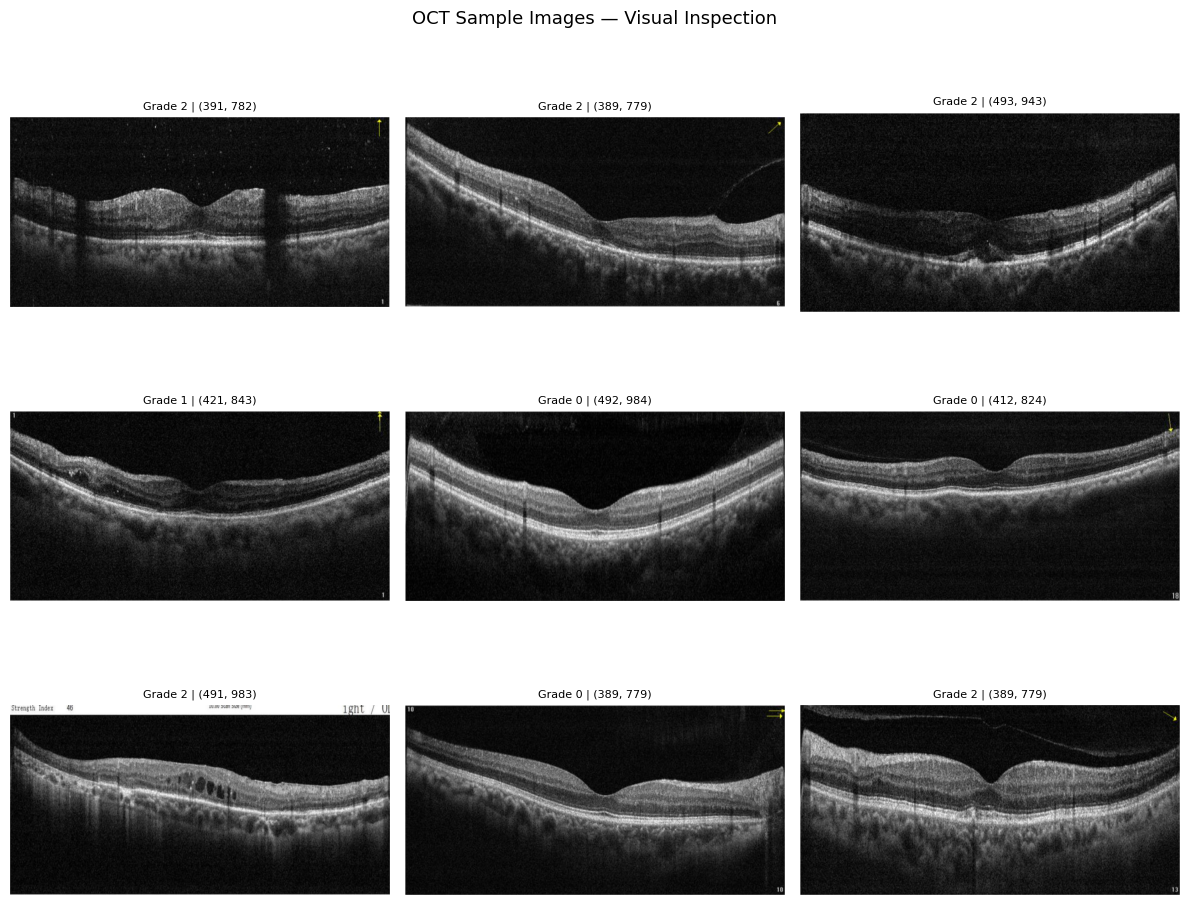

  Sample dimensions (first): (391, 782)
  Mean aspect ratio (H/W): 0.50
  Mean cross-channel variance: 0.01
  → Non-square aspect → B-SCAN
  CSV columns  : ['type', 'image', 'grade', 'lesion', 'lr']
  Has dr_grade : False
  Grade values : [0, 1, 2]
  OCT_IMAGE_TYPE = 'bscan'

[3/7] Reading CSV splits and detecting class count (FIX 6)...
  Train: 2,079 | Val: 297 | Test: 562
  N_OCT_CLASSES = 3

[4/7] Computing class weights...
  Class weights: ['0.511', '2.200', '0.289']

[5/7] Building baseline ResNet-50...
  Parameters: 23,514,179

[6/7] Building baseline DataLoaders (standard transforms)...
  Train: 130 batches | Val: 19 | Test: 36

[7/7] Training OCT baseline ResNet-50...
  Ep   1/30 | loss=0.8476 | val_acc=0.7205 | val_f1=0.6219 | 11s | session=0.01h
  Ep   2/30 | loss=0.6353 | val_acc=0.7643 | val_f1=0.6742 | 10s | session=0.01h
  Ep   3/30 | loss=0.5314 | val_acc=0.8418 | val_f1=0.7399 | 10s | session=0.02h
  Ep   4/30 | loss=0.5034 | val_acc=0.8047 | val_f1=0.6672 | 10s | sessi

In [13]:
# Task 1 — OCT DME Grading: Baseline ResNet-50
#
# Pipeline:
#   1. Extract MMRDR-OCT images (streaming)
#   2. FIX 1: diagnose_oct_images() — determine image type + CSV class count
#   3. FIX 6: Determine N_OCT_CLASSES from CSV BEFORE building any model
#   4. Load CSV splits
#   5. Compute class weights
#   6. Build ResNet-50 baseline
#   7. Train & evaluate
#   8. Log results

print('=' * 65)
print('TASK 1: OCT DME Grading — Baseline ResNet-50')
print(f'Session: {hours_elapsed():.2f}h')
print('=' * 65)


# ── FIX 1 — Image Type Diagnostic ────────────────────────────────────
def diagnose_oct_images(oct_dir, csv_name='OCT.csv', n_samples=9):
    """
    FIX 1: Load sample OCT images, display them, classify image type.
    Runs AFTER extraction, BEFORE model construction.

    Returns:
        image_type  : str   'bscan' | 'enface' | 'unknown'
        has_dr_grade: bool  whether CSV has a dr_grade column
    """
    df         = pd.read_csv(Path(oct_dir) / csv_name)
    sample_rows = df.sample(n=min(n_samples, len(df)), random_state=42)

    fig, axes = plt.subplots(3, 3, figsize=(12, 10))
    dims, color_vars = [], []

    for i, (_, row) in enumerate(sample_rows.iterrows()):
        if i >= 9:
            break
        img_val  = str(row['image'])
        img_path = Path(oct_dir) / img_val
        if not img_path.exists():
            img_path = Path(oct_dir) / 'img' / Path(img_val).name

        img = np.array(Image.open(img_path))
        dims.append(img.shape[:2])

        if img.ndim == 3 and img.shape[2] >= 3:
            channel_means = [img[:, :, c].mean() for c in range(3)]
            color_vars.append(float(np.std(channel_means)))

        ax = axes[i // 3][i % 3]
        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        ax.set_title(f'Grade {row["grade"]} | {img.shape[:2]}', fontsize=8)
        ax.axis('off')

    plt.suptitle('OCT Sample Images — Visual Inspection', fontsize=13)
    plt.tight_layout()
    plt.show()

    aspects        = [h / w for h, w in dims]
    mean_aspect    = float(np.mean(aspects))
    mean_color_var = float(np.mean(color_vars)) if color_vars else 0.0

    print(f'  Sample dimensions (first): {dims[0]}')
    print(f'  Mean aspect ratio (H/W): {mean_aspect:.2f}')
    print(f'  Mean cross-channel variance: {mean_color_var:.2f}')

    if mean_aspect > 1.3 or mean_aspect < 0.7:
        image_type = 'bscan'
        print('  → Non-square aspect → B-SCAN')
    elif mean_color_var < 5.0:
        image_type = 'bscan'
        print('  → Low color variance + near-square → B-SCAN (grayscale-as-RGB)')
    else:
        image_type = 'enface'
        print('  → Color variance + square → EN-FACE / THICKNESS MAP')

    has_dr_grade = 'dr_grade' in df.columns
    print(f'  CSV columns  : {list(df.columns)}')
    print(f'  Has dr_grade : {has_dr_grade}')
    print(f'  Grade values : {sorted(df["grade"].unique().tolist())}')

    return image_type, has_dr_grade


# ── STEP 1: Extract ───────────────────────────────────────────────────
print('\n[1/7] Extracting MMRDR-OCT...')
OCT_DIR = extract_modality('MMRDR-OCT')

# ── STEP 2: FIX 1 — Diagnose image type ──────────────────────────────
print('\n[2/7] Diagnosing OCT image type (FIX 1)...')
OCT_IMAGE_TYPE, HAS_DR_GRADE = diagnose_oct_images(OCT_DIR)
print(f'  OCT_IMAGE_TYPE = {repr(OCT_IMAGE_TYPE)}')

# ── STEP 3: FIX 6 — CSV inspection, class count BEFORE model build ───
print('\n[3/7] Reading CSV splits and detecting class count (FIX 6)...')
oct_train, oct_val, oct_test = load_csv_splits(OCT_DIR, 'OCT.csv')
N_OCT_CLASSES = int(oct_train['grade'].nunique())
print(f'  N_OCT_CLASSES = {N_OCT_CLASSES}')
if N_OCT_CLASSES not in (3, 5):
    print(f'  WARNING: unexpected class count {N_OCT_CLASSES}. Proceeding anyway.')

# ── STEP 4: Compute class weights ────────────────────────────────────
print('\n[4/7] Computing class weights...')
oct_class_weights = compute_class_weights(oct_train, n_classes=N_OCT_CLASSES,
                                           label_col='grade')
print('  Class weights:', [f'{w:.3f}' for w in oct_class_weights.cpu().tolist()])

# ── STEP 5: Build baseline ResNet-50 (FIX 6: n_classes known) ────────
print('\n[5/7] Building baseline ResNet-50...')
oct_baseline = build_resnet50(N_OCT_CLASSES)
n_params = sum(p.numel() for p in oct_baseline.parameters())
print(f'  Parameters: {n_params:,}')

# ── STEP 6: DataLoaders (standard transforms for baseline) ────────────
print('\n[6/7] Building baseline DataLoaders (standard transforms)...')
tr_oct_base, vl_oct_base, ts_oct_base = make_loaders(
    oct_train, oct_val, oct_test, OCT_DIR
)
print(f'  Train: {len(tr_oct_base)} batches | Val: {len(vl_oct_base)} | Test: {len(ts_oct_base)}')

# ── STEP 7: Train & evaluate ──────────────────────────────────────────
print('\n[7/7] Training OCT baseline ResNet-50...')
criterion_base = nn.CrossEntropyLoss(weight=oct_class_weights)
if not session_ok(buffer_hrs=2.0):
    print('  Session limit approaching. Skipping baseline training.')
else:
    oct_base_ckpt = train_task(oct_baseline, tr_oct_base, vl_oct_base,
                               task_name='oct_dme_baseline',
                               criterion=criterion_base)

    # Load best and evaluate
    oct_baseline.load_state_dict(
        torch.load(oct_base_ckpt, map_location=DEVICE, weights_only=True)
    )
    acc_base, f1_base = evaluate(oct_baseline, ts_oct_base)
    log_results('OCT_DME_Baseline', acc_base, f1_base)

    # Free baseline model memory
    del oct_baseline
    torch.cuda.empty_cache()

print('\nTask 1 complete.')


## Task 2 — OCT DME Grading: OCT GAT (Phase 3)


TASK 2: OCT DME Grading — OCT GAT Phase 3
Session: 0.06h
  OCT_DIR        = /kaggle/working/mmrdr_extracted/MMRDR-OCT
  OCT_IMAGE_TYPE = bscan  (FIX 1)
  N_OCT_CLASSES  = 3   (FIX 6)

[2] Building OCT GAT DataLoaders (oct_train_transform — FIX 5)...
  Train: 130 batches | Val: 19 | Test: 36

[3] Computing class weights...
  Class weights: ['0.511', '2.200', '0.289']

[4] Building OCTGATClassifier (n_classes=3, image_type='bscan')...

Component                    Params     Trainable
--------------------------------------------------
  backbone               23,508,032    23,508,032
  graph_builder                   0             0
  node_proj                 525,056       525,056
  gat_layers                133,120       133,120
  readout                       256           256
  grading_head                  771           771
  aux_head                    6,147         6,147
--------------------------------------------------
  TOTAL                  24,173,382
  Image type: bscan
  n_

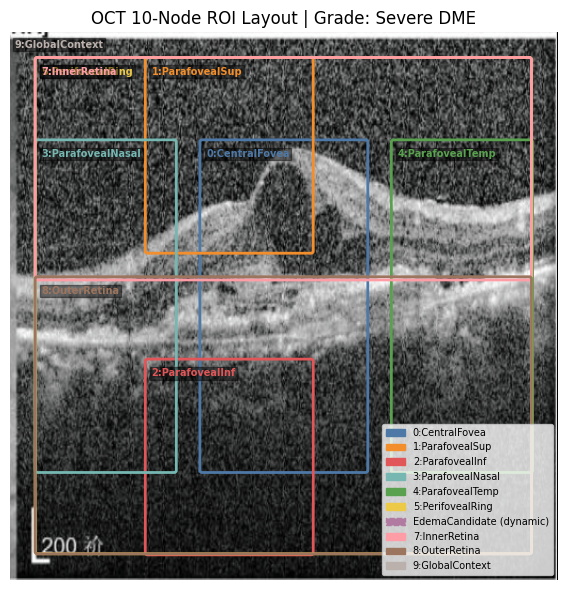


[7] Debug forward pass...
  images    : torch.Size([2, 3, 512, 512])
  logits    : torch.Size([2, 3])  dtype=torch.float32
  aux_logits: torch.Size([2, 3])
  attn      : torch.Size([2, 10])  dtype=torch.float32
  Attention dtype: torch.float32  (should be float32 — FIX 8)
  logits range: [-0.453, 0.884]
  ✓ Debug forward pass passed.

[8] Training OCT GAT (image_type=bscan, n_classes=3)...
  Ep   1/30 | loss=1.1899 | val_acc=0.7643 | val_f1=0.6290 | 8s | session=0.06h
  Ep   2/30 | loss=0.9587 | val_acc=0.7374 | val_f1=0.6444 | 7s | session=0.06h
  Ep   3/30 | loss=0.9182 | val_acc=0.7946 | val_f1=0.6973 | 8s | session=0.07h
  Ep   4/30 | loss=0.7819 | val_acc=0.8283 | val_f1=0.7041 | 8s | session=0.07h
  Ep   5/30 | loss=0.7844 | val_acc=0.8485 | val_f1=0.7058 | 7s | session=0.07h
  Ep   6/30 | loss=0.7397 | val_acc=0.8350 | val_f1=0.7124 | 8s | session=0.07h
  Ep   7/30 | loss=0.6955 | val_acc=0.7003 | val_f1=0.6303 | 8s | session=0.07h
  Ep   8/30 | loss=0.6814 | val_acc=0.8451 | v

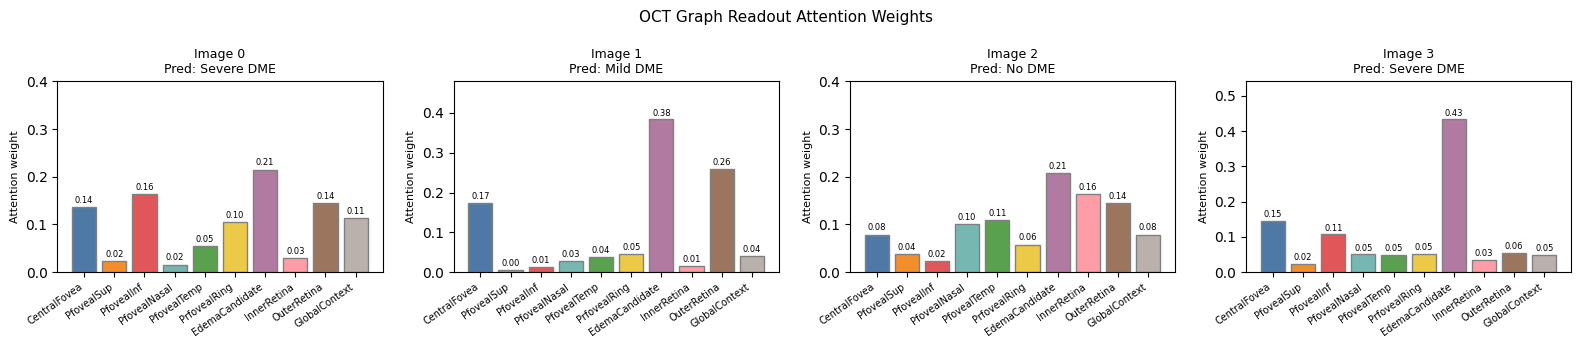


  OCT GAT model freed from GPU.

Task 2 complete.


In [14]:
# Task 2 — OCT DME Grading: OCT Graph Attention Network (Phase 3)
#
# Prerequisites:
#   - Cells 7B, 7C, 8B, 9 executed
#   - OCT images extracted (OCT_DIR valid)
#   - OCT_IMAGE_TYPE, N_OCT_CLASSES set by Task 1  (FIX 1, 6)
#
# Pipeline:
#   1. Verify prerequisites
#   2. DataLoaders (oct transforms, 2-tuple — FIX 4)
#   3. Build OCTGATClassifier (n_classes + image_type known — FIX 6)
#   4. Print model summary + graph topology
#   5. Visualise 10-node ROI layout on a sample image
#   6. Debug forward pass (shapes, NaN, attention dtype — FIX 8)
#   7. Train (weighted CE + AMP + grad clipping)
#   8. Load best checkpoint (with arch validation)
#   9. Evaluate on test set
#  10. Compare with baseline
#  11. Visualise attention weights
#  12. Optional DR grade experiment (if HAS_DR_GRADE)
#  13. GPU cleanup

print('=' * 65)
print('TASK 2: OCT DME Grading — OCT GAT Phase 3')
print(f'Session: {hours_elapsed():.2f}h')
print('=' * 65)

# ── 1. Verify prerequisites ───────────────────────────────────────────
if 'OCT_DIR' not in globals() or not Path(OCT_DIR).exists():
    raise RuntimeError(
        'OCT_DIR is not set or does not exist.\n'
        'Run Task 1 first to extract images and run diagnose_oct_images().'
    )
if 'OCT_IMAGE_TYPE' not in globals():
    raise RuntimeError(
        'OCT_IMAGE_TYPE not set. Run Task 1 first (diagnose_oct_images is called there).'
    )
if 'N_OCT_CLASSES' not in globals():
    raise RuntimeError(
        'N_OCT_CLASSES not set. Run Task 1 first (CSV inspection happens there — FIX 6).'
    )

print(f'  OCT_DIR        = {OCT_DIR}')
print(f'  OCT_IMAGE_TYPE = {OCT_IMAGE_TYPE}  (FIX 1)')
print(f'  N_OCT_CLASSES  = {N_OCT_CLASSES}   (FIX 6)')

# ── 2. DataLoaders (OCT transforms, 2-tuple — FIX 4) ─────────────────
print('\n[2] Building OCT GAT DataLoaders (oct_train_transform — FIX 5)...')
# oct_train, oct_val, oct_test already set in Task 1
tr_oct, vl_oct, ts_oct = make_oct_loaders(oct_train, oct_val, oct_test, OCT_DIR)
print(f'  Train: {len(tr_oct)} batches | Val: {len(vl_oct)} | Test: {len(ts_oct)}')

# ── 3. Compute class weights (FIX 6: n_classes already known) ─────────
print('\n[3] Computing class weights...')
oct_class_weights = compute_class_weights(oct_train, n_classes=N_OCT_CLASSES,
                                           label_col='grade')
print('  Class weights:', [f'{w:.3f}' for w in oct_class_weights.cpu().tolist()])

# ── 4. Build OCT GAT model (FIX 6: n_classes + image_type pre-determined) ──
print(f'\n[4] Building OCTGATClassifier (n_classes={N_OCT_CLASSES}, '
      f'image_type={repr(OCT_IMAGE_TYPE)})...')
oct_gat_model = build_oct_gat_model(
    n_classes=N_OCT_CLASSES,
    image_type=OCT_IMAGE_TYPE,
    proj_dim=256, n_heads=4, n_gat_layers=2,
    dropout=0.1, aux_weight=0.3,
)
print()
print_oct_model_summary(oct_gat_model, image_type=OCT_IMAGE_TYPE)

# ── 5. Print graph topology ───────────────────────────────────────────
print()
print_oct_adjacency(image_type=OCT_IMAGE_TYPE)

# ── 6. Visualise ROI regions on a sample OCT image ───────────────────
print('\n[6] Visualising 10-node ROI layout on a sample OCT image...')
_oct_sample_ds  = MMRDRGradingDataset(oct_train.head(1), OCT_DIR, oct_val_transform)
_oct_sample_img, _oct_sample_lbl = _oct_sample_ds[0]
_grade_name = DME_GRADE_NAMES.get(_oct_sample_lbl, str(_oct_sample_lbl))
visualize_oct_roi_regions(
    _oct_sample_img,
    image_type=OCT_IMAGE_TYPE,
    title=f'OCT 10-Node ROI Layout | Grade: {_grade_name}',
)

# ── 7. Debug forward pass (FIX 8: attention dtype check) ─────────────
print('\n[7] Debug forward pass...')
debug_oct_forward(oct_gat_model, n_images=2)

# ── 8. Train ──────────────────────────────────────────────────────────
if not session_ok(buffer_hrs=1.0):
    print('\nSession limit approaching. Skipping OCT GAT training.')
else:
    print(f'\n[8] Training OCT GAT (image_type={OCT_IMAGE_TYPE}, '
          f'n_classes={N_OCT_CLASSES})...')
    oct_gat_ckpt = train_task_oct(
        oct_gat_model, tr_oct, vl_oct,
        task_name='oct_dme_gat_phase3',
        class_weights=oct_class_weights,
        aux_weight=0.3,
    )

    # ── 9. Load best checkpoint ──────────────────────────────────────
    print('\n[9] Loading best checkpoint...')
    load_oct_checkpoint(oct_gat_model, oct_gat_ckpt)

    # ── 10. Evaluate on test set ─────────────────────────────────────
    print('\n[10] Evaluating on test set...')
    acc_oct, f1_oct, test_attn = evaluate_oct(oct_gat_model, ts_oct)
    log_results('OCT_DME_GAT_Phase3', acc_oct, f1_oct)

    # ── 11. Comparison table ─────────────────────────────────────────
    print()
    print('  ─── Performance Comparison ──────────────────────────────')
    for key in ['OCT_DME_Baseline', 'OCT_DME_GAT_Phase3']:
        r = RESULTS.get(key)
        if r:
            print(f'  {key:<28} acc={r["acc"]:.4f}  f1={r["f1"]:.4f}')
    print()

    # ── 12. Visualise attention weights ─────────────────────────────
    print('\n[12] Visualising readout attention on test samples...')
    _vis_imgs, _vis_lbls = next(iter(ts_oct))
    _vis_imgs_d = _vis_imgs.to(DEVICE)
    with torch.no_grad():
        with _autocast_oct():
            _vis_logits, _, _vis_attn = oct_gat_model(_vis_imgs_d)
    _vis_preds = _vis_logits.argmax(dim=1).cpu().numpy()

    visualize_oct_attention(
        _vis_attn,
        grade_preds=_vis_preds,
        grade_names=DME_GRADE_NAMES,
        image_type=OCT_IMAGE_TYPE,
        max_show=4,
    )

    # ── 13. Optional DR grade experiment ────────────────────────────
    if HAS_DR_GRADE:
        print('\n[13] DR Grade column detected. Running secondary DR experiment...')
        n_dr_classes = int(oct_train['dr_grade'].nunique())
        print(f'  DR grade classes: {n_dr_classes}')
        oct_dr_model = build_oct_gat_model(
            n_classes=n_dr_classes,
            image_type=OCT_IMAGE_TYPE,
        )
        # Build DR-grade splits (reuse same images, different label column)
        oct_train_dr = oct_train.copy().rename(columns={'dr_grade': 'grade'})
        oct_val_dr   = oct_val.copy().rename(columns={'dr_grade': 'grade'})
        oct_test_dr  = oct_test.copy().rename(columns={'dr_grade': 'grade'})
        tr_oct_dr, vl_oct_dr, ts_oct_dr = make_oct_loaders(
            oct_train_dr, oct_val_dr, oct_test_dr, OCT_DIR)
        dr_weights = compute_class_weights(oct_train_dr, n_classes=n_dr_classes)

        if session_ok(buffer_hrs=0.75):
            oct_dr_ckpt = train_task_oct(
                oct_dr_model, tr_oct_dr, vl_oct_dr,
                task_name='oct_dr_gat_phase3',
                class_weights=dr_weights,
                aux_weight=0.3,
            )
            load_oct_checkpoint(oct_dr_model, oct_dr_ckpt)
            acc_dr, f1_dr, _ = evaluate_oct(oct_dr_model, ts_oct_dr)
            log_results('OCT_DR_GAT_Phase3', acc_dr, f1_dr)
        else:
            print('  Session limit too close. Skipping DR grade training.')
        del oct_dr_model

    # ── 14. GPU cleanup ──────────────────────────────────────────────
    _cleanup_oct(oct_gat_model)
    print('\n  OCT GAT model freed from GPU.')

print('\nTask 2 complete.')


## Summary — All OCT Results


In [15]:
print('\n' + '=' * 65)
print('OCT MODALITY — FINAL RESULTS SUMMARY')
print('=' * 65)
print(f'  Image type  : {OCT_IMAGE_TYPE!r}')
print(f'  N classes   : {N_OCT_CLASSES}')
print(f'  Node names  : {_BSCAN_NODE_NAMES if OCT_IMAGE_TYPE == "bscan" else _ENFACE_NODE_NAMES}')
print()
print(f'  {"Task":<30} {"Acc":>8} {"Macro-F1":>10}')
print('  ' + '-' * 52)
for key in sorted(RESULTS.keys()):
    r = RESULTS[key]
    print(f'  {key:<30} {r["acc"]:>8.4f} {r["f1"]:>10.4f}')
print()
print(f'  Session elapsed: {hours_elapsed():.2f}h')
print('=' * 65)



OCT MODALITY — FINAL RESULTS SUMMARY
  Image type  : 'bscan'
  N classes   : 3
  Node names  : ['CentralFovea', 'ParafovealSup', 'ParafovealInf', 'ParafovealNasal', 'ParafovealTemp', 'PerifovealRing', 'EdemaCandidate', 'InnerRetina', 'OuterRetina', 'GlobalContext']

  Task                                Acc   Macro-F1
  ----------------------------------------------------
  OCT_DME_Baseline                 0.9057     0.7618
  OCT_DME_GAT_Phase3               0.8772     0.7768

  Session elapsed: 0.10h
